# Explore the Model

Local companion to [`content/05-explore.md`](../content/05-explore.md), which is the same
material running in the browser via JupyterLite/Pyodide on the published site.

The difference is only the setup. The web version has to ship a wheel and install it with
`micropip`; here the package is already importable, so that whole bootstrap is gone. Nothing
below depends on the browser — `micropip`, `js` and `pyodide` do not exist outside the
Pyodide kernel, which is why this file exists separately rather than being the same notebook.

**Before running:**

```bash
pip install -e ".[dev]"
```

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from enclose import figures, loci, model

print("enclose", __import__("enclose").__version__)

enclose 0.1.0


## A figure

The same call that produces `social_opt_cond.png` for the paper.

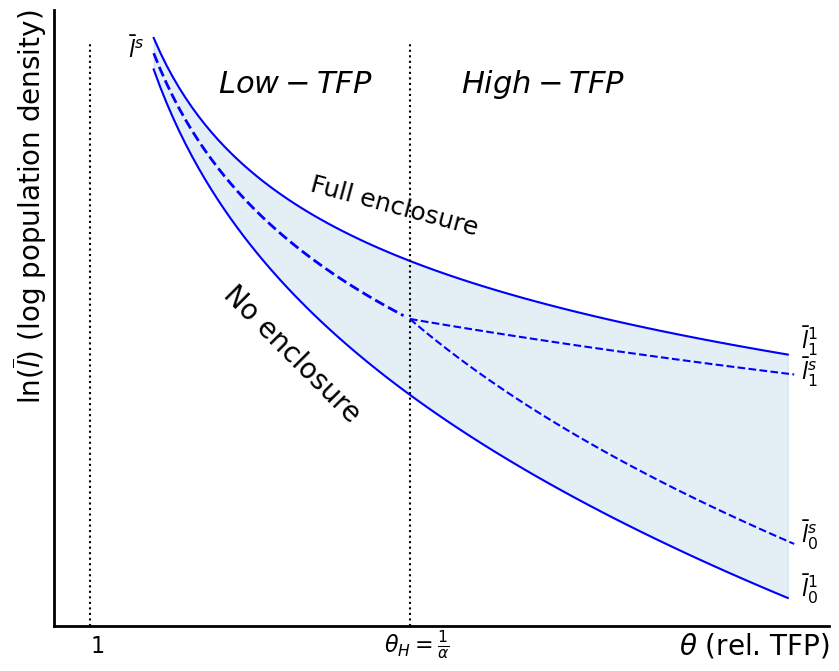

In [2]:
fig, ax = figures.social_optimum(cond_opt=True)

## Closing the wedge: $\mu$ and $\tau$ on one panel

Figure 6 of the paper shows four panels at the corners of the $(\mu, \tau)$ square —
$(0,0)$, $(1,0)$, $(0,1)$, $(1,1)$ — and asks you to interpolate between them in your head.
Here both parameters are continuous on a single panel, so you can watch the interpolation
instead.

- **Black** is the first-best band. It does not move: $\mu$ and $\tau$ are institutions, and
  the first-best is defined without reference to them.
- **Red** is the decentralized band. It moves with both sliders.
- **Dashed blue** are the second-best loci — the constrained planner, who takes the
  decentralized labor allocation as given but chooses $t_e$. These move with $\mu$ **only**.
- The dotted verticals are $\theta = 1$ and $\theta_H^\mu$. The second moves with $\mu$:
  it is $1/\alpha - \mu(1-\alpha)/\alpha$, and it is also where the second-best objective
  switches from convex to concave.

Push both sliders to 1 and the red band lands exactly on the black one. That coincidence is
the paper's Key Result (§5.3) — the wedge closes only when commons governance and
compensation are *both* complete. Neither alone suffices: check by pushing one slider to 1
while leaving the other at 0.

In [3]:
from ipywidgets import interact, FloatSlider

def wedge(mu=0.0, tau=0.0):
    fig, ax = figures.wedge_panel(mu=mu, tau=tau)
    plt.show()

interact(
    wedge,
    mu=FloatSlider(value=0.0, min=0.0, max=1.0, step=0.05,
                   description=r"$\mu$ (governance)", style={"description_width": "initial"}),
    tau=FloatSlider(value=0.0, min=0.0, max=1.0, step=0.05,
                    description=r"$\tau$ (compensation)", style={"description_width": "initial"}),
);

interactive(children=(FloatSlider(value=0.0, description='$\\mu$ (governance)', max=1.0, step=0.05, style=Slid…

> **Why the blue curves respond to $\mu$ but not to $\tau$**
>
> The second-best planner respects the labor allocation that emerges from decentralized
> labor markets but can control the enclosure rate (appendix §4.1). Governance changes that
> allocation — $\Lambda \to \Lambda_\mu$ runs right through the objective — so the
> constrained optimum moves with $\mu$. Compensation does not: $\tau$ is a transfer from
> encloser to commoners, so it cancels out of total output and cannot shift a locus derived
> from the planner's output margin. It moves the red private loci alone. The paper's
> Figure 6 says the same thing without commenting on it: panel (c) is $\mu=0,\tau=1$ and
> carries exactly the blue curves of panel (a), $\mu=0,\tau=0$.
>
> Two of the three move. Eq. (18), the low-TFP full-versus-none comparison, is
> $\mu$-invariant — it compares $t_e=0$ against $t_e=1$, and at neither corner is there a
> partly-enclosed commons for governance to act on.

> **Why the dashed red curve disappears in the interior**
>
> The dashed red curve is the global-games selection locus, drawn only when one of the two
> parameters is zero. `ln_gg` is extended in $\tau$ but derived for $\mu=0$; `ln_gg_mu` is
> extended in $\mu$ but derived for $\tau=0$. A combined $(\mu,\tau)$ risk-dominance
> threshold appears nowhere in the appendix or the codebase. Rather than draw one of the
> one-sided loci where neither applies, the panel omits it and labels the omission — the two
> are not the same object, and interpolating between them would be inventing a result.

The four corners, side by side, are the paper's Figure 6:

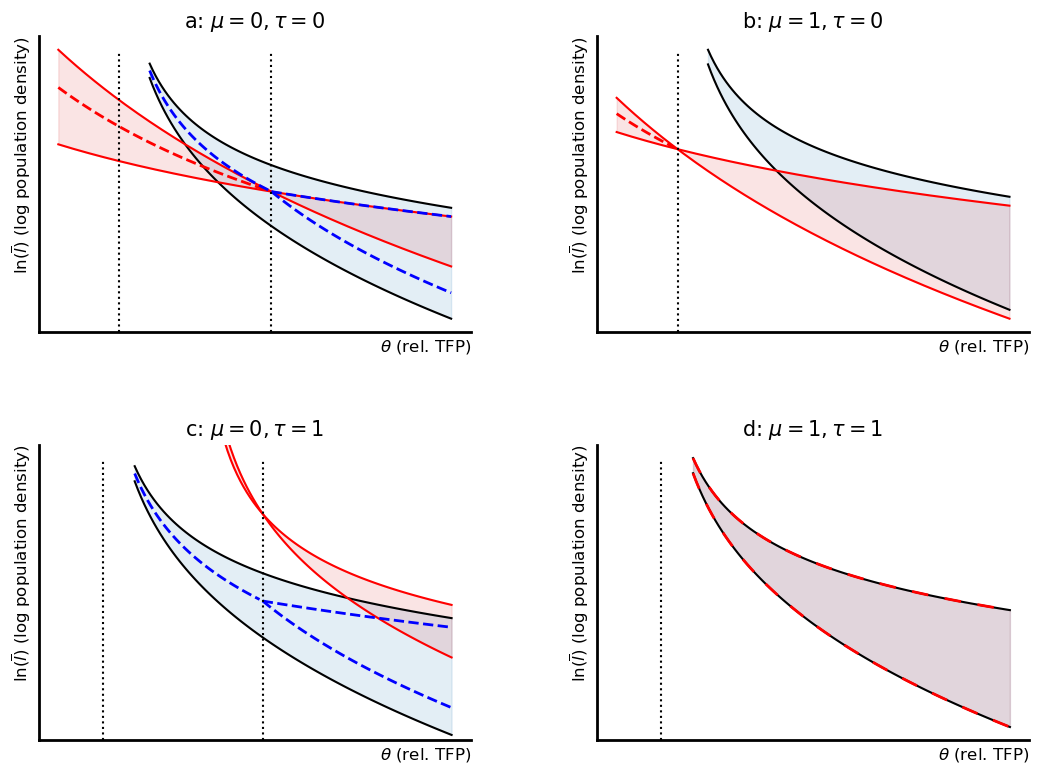

In [4]:
fig, ax = figures.combined_4x4()

## Going further

Every locus is a plain function of $\theta$, so anything above can be rebuilt from parts.
Edit and re-run.

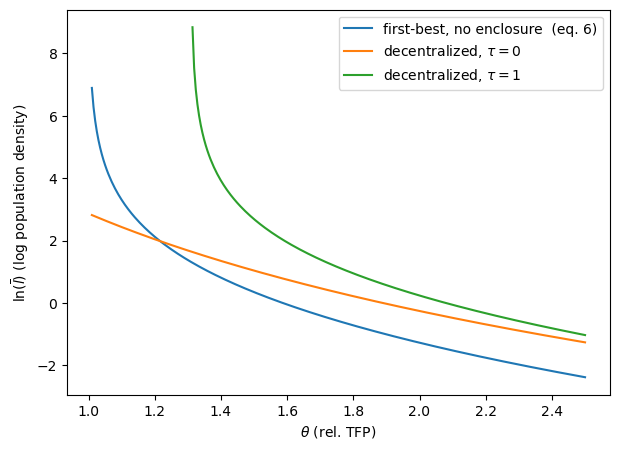

In [5]:
theta = np.linspace(1.01, 2.5, 300)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(theta, loci.ln_l01(theta), label=r"first-best, no enclosure  (eq. 6)")
ax.plot(theta, loci.ln_ld0(theta), label=r"decentralized, $\tau=0$")
ax.plot(theta, loci.ln_ld0(theta, tau=1.0), label=r"decentralized, $\tau=1$")
ax.set_xlabel(r"$\theta$ (rel. TFP)")
ax.set_ylabel(r"$\ln(\overline{l})$ (log population density)")
ax.legend()
plt.show()

## The parameters

All diagrams use the paper's calibration, $\alpha = 2/3$ and $c/A = 1$, carried as defaults
on the loci. `loci.C` **is** $c/A$, not $c$ — every locus equates a marginal benefit scaling
with $A$ to a marginal cost scaling with $c$, so only the ratio survives.

Two modules are not exercised above and need extras beyond numpy/matplotlib:
`enclose.symbolic` (sympy) re-derives every locus from its objective and checks the numeric
layer against it, and `enclose.manufacturing` (scipy) solves the three-sector equilibrium.
Both are available locally after `pip install -e ".[dev]"`:

```python
from enclose import manufacturing as mfg
mfg.labor_share(te=1.0, b=0.7, alp=0.4, th=1.0)   # ~0.68
```